# Bar Path Model Testing

Predict data using saved model

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load config

In [12]:
import yaml

In [24]:
with open("config.yaml", 'r') as stream:
    try:
        config = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

API_KEY = config['API_KEY']
BASE_ID = config['BASE_ID']
TABLE_NAME = config['TABLE_NAME']

DATA_COLUMNS = config['DATA_COLUMNS']
EXERCISE_TYPES = config['EXERCISE_TYPES']

SAMPLE_RATE = config['SAMPLE_RATE']
CUTOFF_FREQ = config['CUTOFF_FREQ']
WINDOW_SIZE = config['WINDOW_SIZE']
STEP_SIZE = config['STEP_SIZE']

MIN_REPS = config['MIN_REPS']

### Load data from AirTable

In [14]:
from ast import literal_eval
from pyairtable import Api as airtable_api

In [25]:
FORMULA = f"AND({{ValidData}} = 'true', {{StartRepTime}} != '', " f"{{EndRepTime}} != '', {{Reps}} >= '{str(MIN_REPS)}')"

In [16]:
def to_numpy(data):
    return np.array(literal_eval(data))

def to_float(data):
    return float(data)

In [26]:
api = airtable_api(API_KEY)
table = api.table(BASE_ID, TABLE_NAME)

matches = table.all(formula=FORMULA)
print("Number of matching records: ", len(matches))

Number of matching records:  202


In [20]:
data_dict = []

for match in matches:
    data = match['fields']
    
    data_dict.append({
        'Date': data.get('Date'),
        'Exercise': data.get('Exercise'),
        'Lifter': data.get('Lifter'),
        'WorkoutTime': data.get('WorkoutTime'),
        'Reps': data.get('Reps'),
        'Weight': data.get('Weight'),
        'Intensity': data.get('Intensity'),
        'Notes': data.get('Notes'),
        'StartRepTime': data.get('StartRepTime'),
        'EndRepTime': data.get('EndRepTime'),
        'Counter': to_numpy(data.get('Counter')),
        'TimeBetweenSamples': to_numpy(data.get('TimeBetweenSamples')),
        'AccX': to_numpy(data.get('AccX')),
        'AccY': to_numpy(data.get('AccY')),
        'AccZ': to_numpy(data.get('AccZ')),
        'Pitch': to_numpy(data.get('Pitch')),
        'Roll': to_numpy(data.get('Roll')),
        'Yaw': to_numpy(data.get('Yaw')),
        'HeartRate': to_numpy(data.get('HeartRate')),
    })

df = pd.concat([pd.DataFrame([d]) for d in data_dict], ignore_index=True)
df

,Date,Exercise,Lifter,WorkoutTime,Reps,Weight,Intensity,Notes,StartRepTime,EndRepTime,Counter,TimeBetweenSamples,AccX,AccY,AccZ,Pitch,Roll,Yaw,HeartRate
0,"Apr 16, 2024 at 4:45:01 PM",Horizontal Chest Press,Anwar,28.69,8,145,10,None,6.72,25.34,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[222003, 10, 9, 10, 10, 10, 12, 7, 10, 10, 10,...","[0.254, 0.409, -0.13, -0.019, 0.234, 0.331, 0....","[0.819, -0.072, -0.617, -1.169, -0.67, 0.128, ...","[0.095, 0.315, 0.715, 0.66, 0.735, 0.698, 0.82...","[0.667, 0.674, 0.676, 0.683, 0.694, 0.704, 0.7...","[0.057, 0.059, 0.063, 0.068, 0.074, 0.078, 0.0...","[-0.02, -0.022, -0.027, -0.034, -0.038, -0.04,...","[84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 8..."
1,"Apr 27, 2024 at 11:07:05 AM",Squat,Anwar,46.75,7,225,9,None,16.08,39.98,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[242417, 13, 7, 9, 11, 9, 10, 10, 10, 12, 8, 1...","[0.119, -0.129, -0.155, -0.134, -0.003, 0.076,...","[0.138, -0.047, -0.156, -0.166, -0.181, -0.138...","[0.152, 0.149, 0.097, 0.144, 0.222, 0.199, 0.0...","[0.526, 0.528, 0.529, 0.529, 0.528, 0.527, 0.5...","[0.023, 0.022, 0.022, 0.022, 0.022, 0.022, 0.0...","[-0.006, -0.005, -0.005, -0.005, -0.004, -0.00...","[124, 124, 124, 124, 124, 124, 124, 124, 124, ..."
2,"Mar 2, 2024 at 3:35:29 PM",DB Side Raise,Anwar,32.91,12,27.5,8,None,4.05,30.96,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[95273, 10, 11, 11, 8, 11, 10, 9, 11, 9, 10, 1...","[-0.151, 0.003, -0.038, 0.02, 0.008, -0.123, -...","[0.203, 0.355, 0.324, 0.137, 0.029, -0.009, 0....","[-0.006, -0.054, -0.154, -0.193, -0.148, -0.10...","[0.401, 0.402, 0.403, 0.404, 0.405, 0.405, 0.4...","[0.123, 0.124, 0.124, 0.124, 0.124, 0.123, 0.1...","[-0.025, -0.025, -0.024, -0.023, -0.023, -0.02...","[123, 123, 123, 123, 123, 123, 123, 123, 123, ..."
3,"Apr 25, 2024 at 5:39:23 PM",DB Bench,Anwar,50.13,8,90,9,None,20.37,40,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[211265669, 5, 8, 11, 9, 12, 8, 10, 11, 10, 11...","[0.037, 0.006, -0.063, -0.014, -0.013, -0.023,...","[0.083, 0.018, 0.037, 0.047, 0.015, 0.009, 0.0...","[0.064, 0.07, 0.072, 0.079, 0.063, 0.046, 0.02...","[0.116, 0.117, 0.117, 0.117, 0.116, 0.116, 0.1...","[0.202, 0.202, 0.202, 0.202, 0.201, 0.201, 0.2...","[-0.012, -0.011, -0.011, -0.011, -0.01, -0.01,...","[97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 9..."
4,"Mar 7, 2024 at 7:08:21 AM",Ab Rollout,Anwar,48.09,10,BW,7,None,3.76,42.51,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[90200, 9, 10, 10, 10, 12, 8, 11, 9, 10, 10, 1...","[-0.079, -0.099, -0.128, -0.087, -0.097, 0.003...","[-0.074, -0.097, -0.104, -0.113, -0.133, -0.16...","[0.177, 0.132, 0.157, 0.216, 0.249, 0.254, 0.2...","[0.254, 0.254, 0.255, 0.254, 0.253, 0.252, 0.2...","[0.058, 0.058, 0.058, 0.058, 0.058, 0.058, 0.0...","[-0.007, -0.007, -0.007, -0.006, -0.006, -0.00...","[95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 9..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,"Mar 9, 2024 at 4:58:46 PM",DB Deadlift,Anwar,35.30,10,85,7,None,4.75,29.10,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[244571, 13, 4, 10, 10, 10, 10, 10, 12, 7, 12,...","[0.063, 0.147, 0.271, 0.143, 0.202, 0.147, -0....","[0.318, 0.511, 0.429, 0.323, 0.104, -0.049, -0...","[-0.209, -0.099, -0.086, -0.082, -0.008, 0.089...","[0.483, 0.484, 0.486, 0.488, 0.49, 0.49, 0.49,...","[0.055, 0.054, 0.054, 0.053, 0.051, 0.05, 0.04...","[-0.013, -0.014, -0.014, -0.014, -0.013, -0.01...","[116, 116, 116, 116, 116, 116, 116, 116, 116, ..."
198,"Mar 23, 2024 at 11:07:32 AM",DB Bench,Anwar,34.10,10,85,8,None,6.25,23.83,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[10403, 11, 6, 10, 10, 12, 8, 10, 10, 10, 10, ...","[0.052, 0.113, -0.024, 0.064, 0.147, -0.035, -...","[0.001, 0.05, -0.107, -0.043, -0.0, -0.162, -0...","[0.14, 0.121, 0.098, 0.115, 0.133, 0.059, -0.0...","[-0.08, -0.079, -0.08, -0.08, -0.08, -0.081, -...","[-0.147, -0.147, -0.147, -0.147, -0.148, -0.14...","[-0.006, -0.007, -0.007, -0.008, -0.0

## Test the exercise classifier

### Load the data

In [35]:
import pickle as pkl
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks

In [33]:
with open('models/exercise/model.pkl', 'rb') as f:
    clf = pkl.load(f)

with open('models/exercise/label_encoder.pkl', 'rb') as f:
    le = pkl.load(f)

In [36]:
fm = {
    'Mean': np.mean,
    'Std': np.std,
    'AbsDev': lambda x: np.mean(np.abs(x - np.mean(x))),
    'Median': np.median,
    'MedianAbsDev': lambda x: np.median(np.abs(x - np.median(x))),
    'IQR': lambda x: np.percentile(x, 75) - np.percentile(x, 25),
    'NegCount': lambda x: np.sum(x < 0),
    'PosCount': lambda x: np.sum(x > 0),
    'AboveMeanCount': lambda x: np.sum(x > np.mean(x)),
    'NumPeaks': lambda x: len(find_peaks(x)[0]),
    'Energy': lambda x: np.sum(x ** 2),
    'Skewness': skew,
    'Kurtosis': kurtosis,
    'AvgResultantAcc': lambda x: np.mean(np.sqrt(x ** 2)),
    'SMA': lambda x: np.sum(np.abs(x))
}

### Apply transforms

In [38]:
from scipy.integrate import cumulative_trapezoid
from scipy.signal import filtfilt, butter

In [42]:
# Apply pos x to the data

def filter(data, cutoff_freq, sample_rate):
    b, a = butter(1, 2 * cutoff_freq / (sample_rate), btype="highpass")
    return filtfilt(b, a, data)


df['AccX'] = df['AccX'].apply(lambda x: filter(x, CUTOFF_FREQ, SAMPLE_RATE))
df['AccY'] = df['AccY'].apply(lambda x: filter(x, CUTOFF_FREQ, SAMPLE_RATE))
df['AccZ'] = df['AccZ'].apply(lambda x: filter(x, CUTOFF_FREQ, SAMPLE_RATE))

df['VelX'] = df['AccX'].apply(lambda x: cumulative_trapezoid(x, dx=1/SAMPLE_RATE))
df['VelY'] = df['AccY'].apply(lambda x: cumulative_trapezoid(x, dx=1/SAMPLE_RATE))
df['VelZ'] = df['AccZ'].apply(lambda x: cumulative_trapezoid(x, dx=1/SAMPLE_RATE))

df['PosX'] = df['VelX'].apply(lambda x: cumulative_trapezoid(x, dx=1/SAMPLE_RATE))
df['PosY'] = df['VelY'].apply(lambda x: cumulative_trapezoid(x, dx=1/SAMPLE_RATE))
df['PosZ'] = df['VelZ'].apply(lambda x: cumulative_trapezoid(x, dx=1/SAMPLE_RATE))


In [40]:
## Extract features from data
def extract_features(data):
    features = {}
    for col in DATA_COLUMNS:
        for key, func in fm.items():
            features[col + '_' + key] = func(data[col])
    return features

### Predict the exerise of a random record

Predicted exercise:  Lat Pulldown
Actual exercise:  Lat Pulldown


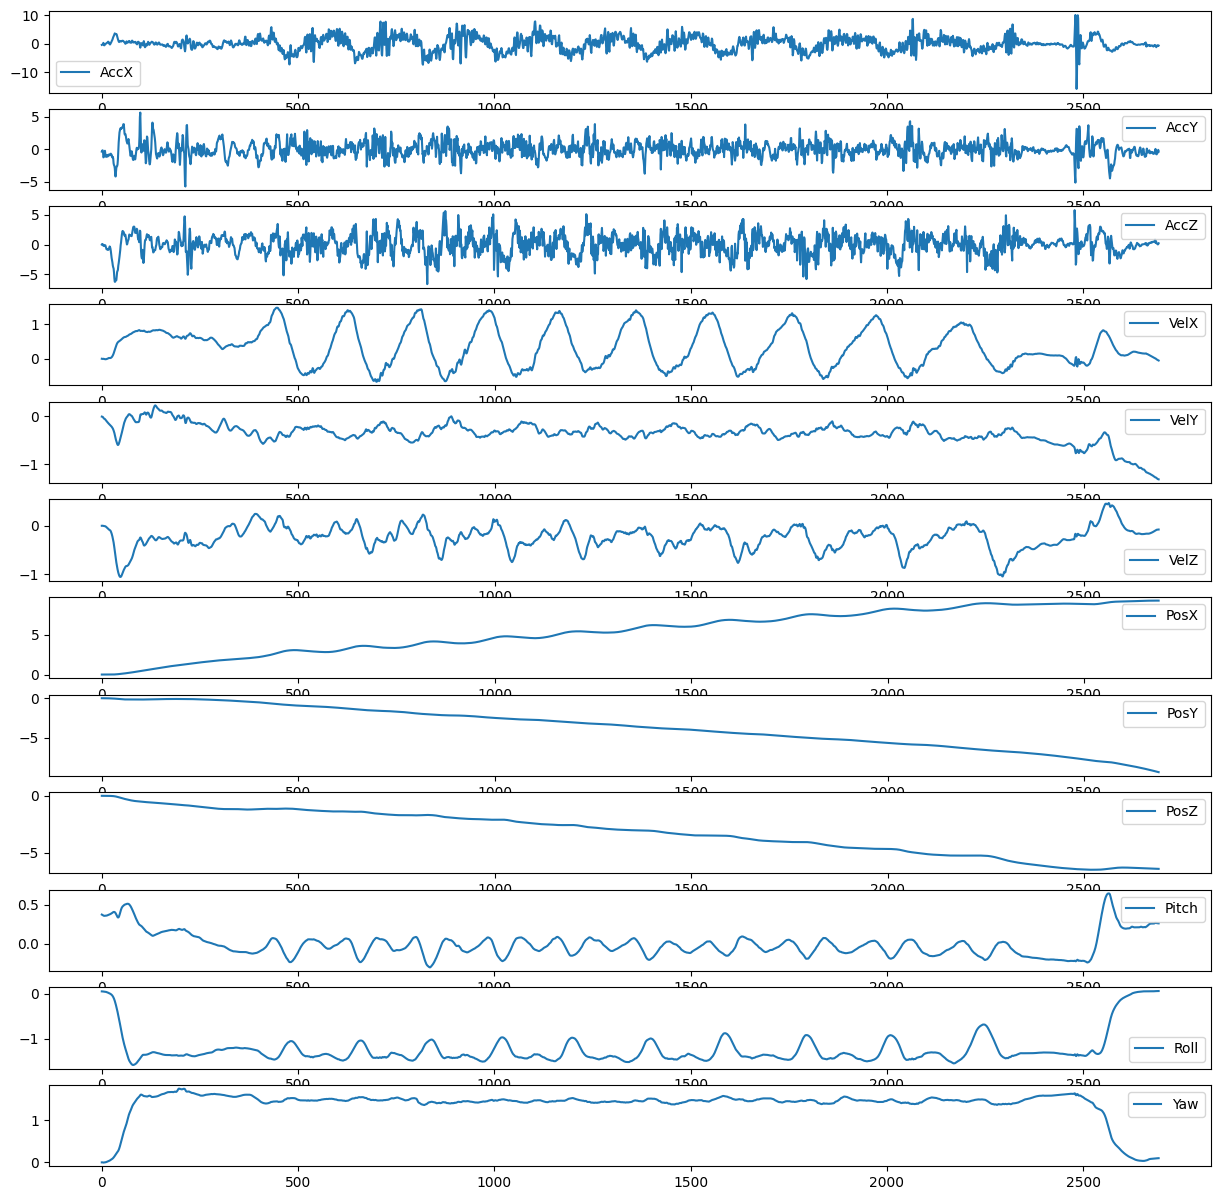

In [43]:
def predict_exercise(data):
    feature_dict = {}

    for data_column in DATA_COLUMNS:
        for feature_name, feature_func in fm.items():
            feature_dict[f'{data_column}{feature_name}'] = feature_func(data[data_column])

    X = pd.DataFrame(feature_dict, index=[0])
    return le.inverse_transform(clf.predict(X))[0]

# grab a random record

data = df.sample(1).iloc[0]
print("Predicted exercise: ", predict_exercise(data))
print("Actual exercise: ", data['Exercise'])

# plot the data

fig, ax = plt.subplots(12, 1, figsize=(15, 15))

for i, data_column in enumerate(DATA_COLUMNS):
    ax[i].plot(data[data_column], label=data_column)
    ax[i].legend()

plt.show()